# Kaggle note book

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
base_dir = '/kaggle/input/datasets/shuvoalok/raf-db-dataset'
train_dir = os.path.join(base_dir, 'DATASET', 'train')
test_dir = os.path.join(base_dir, 'DATASET', 'test')

train_csv = os.path.join(base_dir, 'train_labels.csv')
test_csv = os.path.join(base_dir, 'test_labels.csv')

train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

In [5]:
def get_real_paths(directory):
    img_dict = {}
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_dict[file] = os.path.relpath(os.path.join(root, file), directory)
    return img_dict

print("\nMapping real image paths from subdirectories...")
train_img_paths = get_real_paths(train_dir)
test_img_paths = get_real_paths(test_dir)

train_df['image'] = train_df['image'].map(lambda x: train_img_paths.get(x, x))
test_df['image'] = test_df['image'].map(lambda x: test_img_paths.get(x, x))

train_df['label'] = train_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)

emotion_map = {
    '1': 'Surprise',
    '2': 'Fear',
    '3': 'Disgust',
    '4': 'Happiness',
    '5': 'Sadness',
    '6': 'Anger',
    '7': 'Neutral'
}


Mapping real image paths from subdirectories...


## Data Checking 

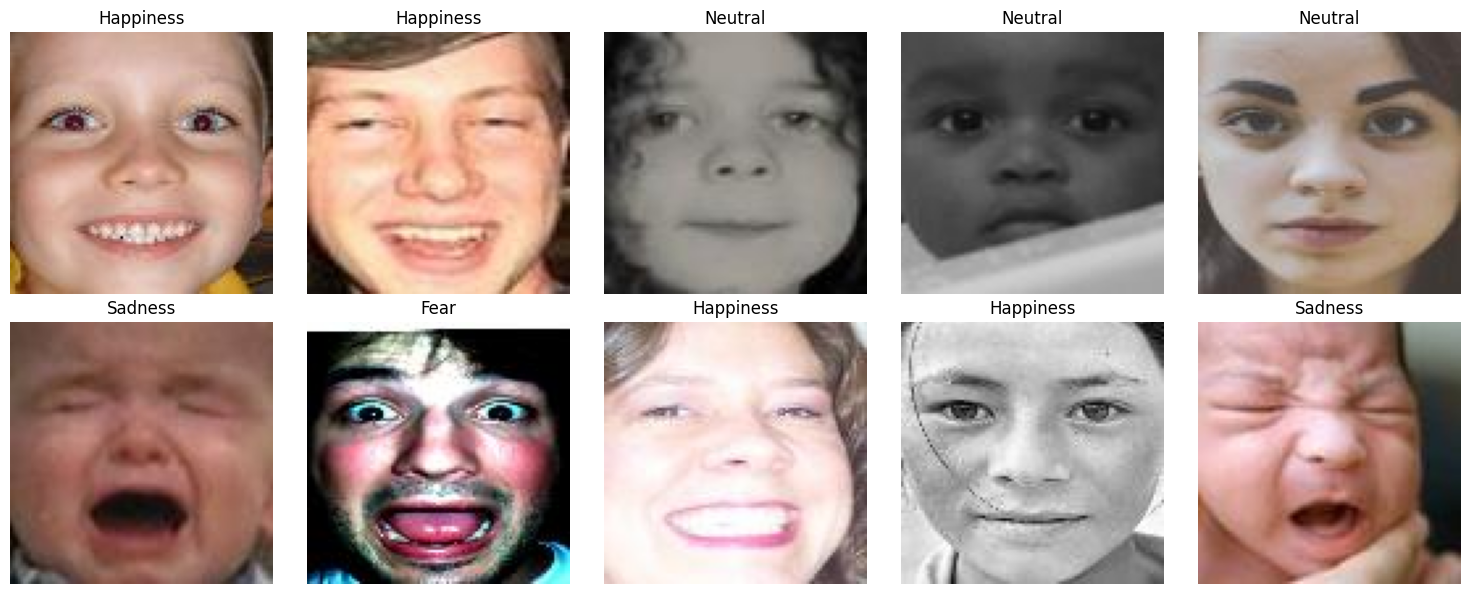

In [7]:
import random

def data_show(df, directory, emotion_map, rows=2, cols=5):
    plt.figure(figsize=(cols * 3, rows * 3))
    
    samples = df.sample(rows * cols).reset_index(drop=True)
    
    for i in range(rows * cols):
        img_path = os.path.join(directory, samples.loc[i, 'image'])
        
        # read image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        label = samples.loc[i, 'label']
        label_name = emotion_map.get(label, label)
        
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(label_name)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

data_show(test_df, test_dir, emotion_map, rows=2, cols=5)

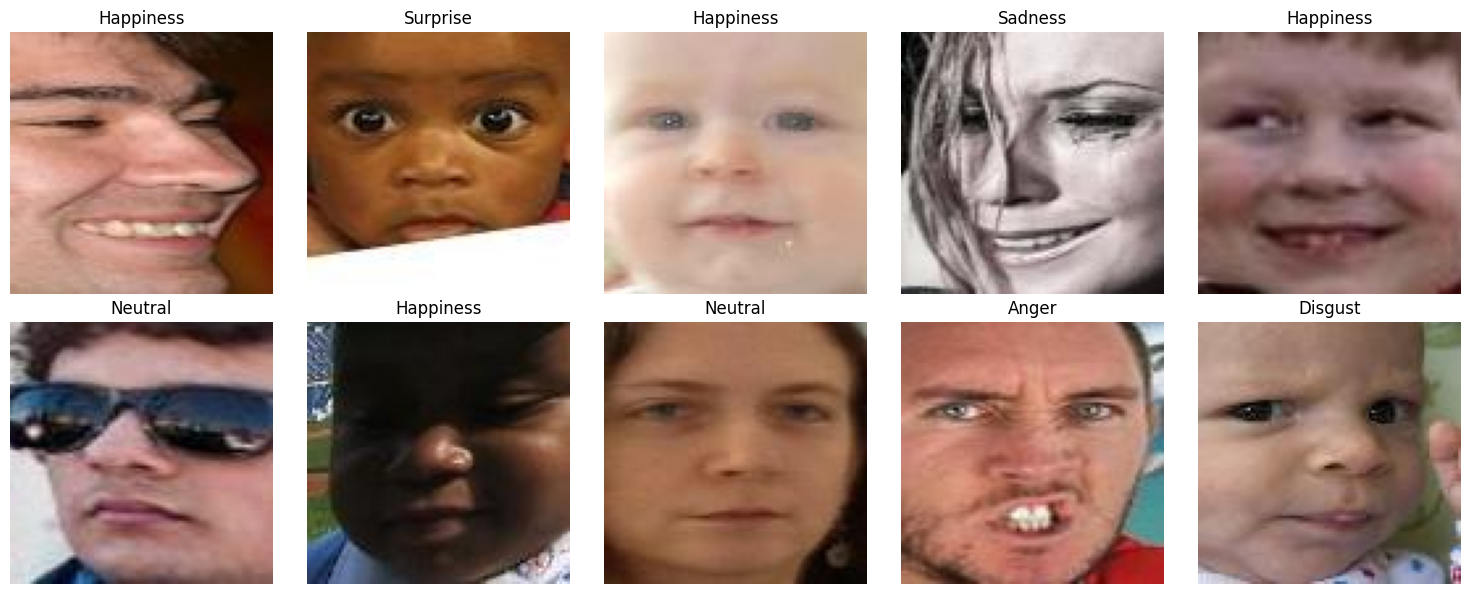

In [10]:
data_show(train_df, train_dir, emotion_map, rows=2, cols=5)

## from tensorflow.keras.preprocessing.image import **ImageDataGenerator**
> Used when dataset is not fit in ram using **ImageDataGenerator**. We can load data in batches that why training take some time.

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

IMG_SIZE = 256
BATCH_SIZE = 64

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=train_dir,
    x_col='image',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    subset='training'
)

val_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=train_dir,
    x_col='image',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    subset='validation'
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory=test_dir,
    x_col='image',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 9817 validated image filenames belonging to 7 classes.
Found 2454 validated image filenames belonging to 7 classes.
Found 3068 validated image filenames belonging to 7 classes.


## Model making

In [8]:
from tensorflow.keras import layers, models

inputs = layers.Input(shape=(None, None, 3))

x = layers.Resizing(224, 224)(inputs)
x = layers.Rescaling(1./255)(x)

In [9]:
from tensorflow.keras.applications import ResNet50
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_tensor=x
)
# freeze
for layer in base_model.layers:
    layer.trainable = False

I0000 00:00:1777294937.135682      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [18]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(1000)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(500)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(500)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(300)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(300)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.4)(x)


x = layers.Dense(128)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(128)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(50)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(7, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.summary()

In [19]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
# Normal LR
model.compile(
    optimizer=Adam(learning_rate=0.01), ## main for transfer learning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# # Dynamic LR
# lr_schedule = ExponentialDecay(
#     initial_learning_rate=1e-2,
#     decay_steps=1000,      
#     decay_rate=0.9,
#     staircase=True
# )

# optimizer = Adam(learning_rate=lr_schedule)

# model.compile(
#     optimizer=optimizer,
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf
import numpy as np
from tensorflow.keras.callbacks import Callback
from sklearn.metrics import confusion_matrix, classification_report

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3, # Wait for 3 epochs
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=0
)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_generator(
    lambda: train_generator,
    output_signature=(
        tf.TensorSpec(shape=(None, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 7), dtype=tf.float32)
    )
).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_generator(
    lambda: val_generator,
    output_signature=(
        tf.TensorSpec(shape=(None, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 7), dtype=tf.float32)
    )
).prefetch(AUTOTUNE)

from tensorflow.keras.callbacks import Callback

class SimpleLogger(Callback):
    def __init__(self, interval=2):
        super().__init__()
        self.interval = interval

    def on_epoch_end(self, epoch, logs=None):
        if epoch == 0 :
            print(f"\nEpoch {epoch+1}")
            print(f"Train Loss: {logs['loss']:.4f}")
            print(f"Train Acc : {logs['accuracy']:.4f}")
            print(f"Val Loss  : {logs['val_loss']:.4f}")
            print(f"Val Acc   : {logs['val_accuracy']:.4f}\n")
            
        if (epoch + 1) % self.interval == 0:
            print(f"\nEpoch {epoch+1}")
            print(f"Train Loss: {logs['loss']:.4f}")
            print(f"Train Acc : {logs['accuracy']:.4f}")
            print(f"Val Loss  : {logs['val_loss']:.4f}")
            print(f"Val Acc   : {logs['val_accuracy']:.4f}\n")

In [26]:
# simple_logger = SimpleLogger(interval=10)

In [30]:
with tf.device('/GPU:0'):
    history = model.fit(
        # train_ds,
        val_ds,
        validation_data=train_ds,
        epochs=10,
        callbacks=[checkpoint], # early_stop, simple_logger
        steps_per_epoch=len(train_generator),
        validation_steps=len(val_generator),
        verbose=1
    )

Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 36s 236ms/step - accuracy: 0.8691 - loss: 0.4081 - val_accuracy: 0.0950 - val_loss: 485.2345
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 37s 238ms/step - accuracy: 0.8725 - loss: 0.3983 - val_accuracy: 0.1042 - val_loss: 934.2863
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 36s 237ms/step - accuracy: 0.8777 - loss: 0.3777 - val_accuracy: 0.1046 - val_loss: 365.1390
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 36s 235ms/step - accuracy: 0.8772 - loss: 0.3800 - val_accuracy: 0.1579 - val_loss: 2437.9248
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 35s 231ms/step - accuracy: 0.8836 - loss: 0.3641 - val_accuracy: 0.0573 - val_loss: 524.4102
Epoch 6/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 33s 215ms/step - accuracy: 0.8851 - loss: 0.3518 - val_accuracy: 0.1006 - val_loss: 1125.0983
Epoch 7/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 33s 214ms/step - accuracy: 0.8862 - loss: 0.3474 - val_accuracy: 0.1014 - val_loss: 468.4864
Epoch 8/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 33s 213ms/step - accuracy: 

In [31]:
model.save("emotion_model.h5")

# Nomal Cnn

In [12]:
from tensorflow.keras import layers, models

inputs = layers.Input(shape=(None, None, 3))

# Preprocessing
x = layers.Resizing(224, 224)(inputs)
x = layers.Rescaling(1./255)(x)

# ===== Block 1 =====
x = layers.Conv2D(128, (4,4), padding='same', activation='relu')(x)
x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = layers.MaxPooling2D(pool_size=(2,2), strides=2)(x)

# ===== Block 2 =====
x = layers.Conv2D(128, (4,4), padding='same', activation='relu')(x)
x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = layers.MaxPooling2D(pool_size=(2,2), strides=2)(x)

# ===== Block 3 =====
x = layers.Conv2D(128, (4,4), padding='same', activation='relu')(x)
x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = layers.MaxPooling2D(pool_size=(2,2), strides=2)(x)

# Flatten
x = layers.Flatten()(x)

# ===== Dense Head =====
x = layers.Dense(500)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(128)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(128)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(50)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)

# Output
outputs = layers.Dense(7, activation='softmax')(x)

Normal_model = models.Model(inputs=inputs, outputs=outputs)

I0000 00:00:1777374717.714177      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [25]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay

# Dynamic LR
lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=1000,
    decay_rate=0.9,
    staircase=True
)

optimizer = Adam(learning_rate=lr_schedule)

Normal_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
Normal_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 128)  │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │    50,176,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 500)            │         2,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 51,240,739 (195.47 MB)

 Trainable params: 51,239,127 (195.46 MB)

 Non-trainable params: 1,612 (6.30 KB)

In [26]:
with tf.device('/GPU:0'):
    history = Normal_model.fit(
        # train_ds,
        train_ds,
        validation_data=val_ds,
        epochs=5,
        callbacks=[checkpoint], # early_stop, simple_logger
        steps_per_epoch=len(train_generator),
        validation_steps=len(val_generator),
        verbose=1
    )

Epoch 1/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 94s 547ms/step - accuracy: 0.9382 - loss: 0.1961 - val_accuracy: 0.7571 - val_loss: 1.0480
Epoch 2/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 74s 483ms/step - accuracy: 0.9482 - loss: 0.1545 - val_accuracy: 0.7714 - val_loss: 1.0915
Epoch 3/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 74s 484ms/step - accuracy: 0.9529 - loss: 0.1456 - val_accuracy: 0.7722 - val_loss: 1.0800
Epoch 4/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 75s 485ms/step - accuracy: 0.9560 - loss: 0.1275 - val_accuracy: 0.7694 - val_loss: 1.1139
Epoch 5/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 74s 483ms/step - accuracy: 0.9608 - loss: 0.1356 - val_accuracy: 0.7474 - val_loss: 1.1988


In [40]:
def data_show_with_pred(df, directory, emotion_map, model, rows=2, cols=5):
    plt.figure(figsize=(cols * 3, rows * 3))
    
    samples = df.sample(rows * cols).reset_index(drop=True)
    
    for i in range(rows * cols):
        img_path = os.path.join(directory, samples.loc[i, 'image'])
        
        # read image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # OG label
        label = samples.loc[i, 'label']
        og_name = emotion_map.get(label, label)
        
        # Prediction
        img_input = cv2.resize(img, (224, 224))
        img_input = np.expand_dims(img_input, axis=0)

        preds = model.predict(img_input, verbose=0)
        pred_class = np.argmax(preds, axis=1)[0]
        pred_name = emotion_map.get(pred_class, pred_class)
        confidence = np.max(preds)

        # # plot
        # plt.subplot(rows, cols, i + 1)
        # plt.imshow(img)
        # plt.title(f"OG: {emotion_map[int(og_name)]}\nPred: {pred_name} ({confidence:.2f})") # og_name keys
        # plt.axis('off')
        # plot
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f"OG: {emotion_map[int(og_name) - 1]}\nPred: {pred_name} ({confidence:.2f})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()



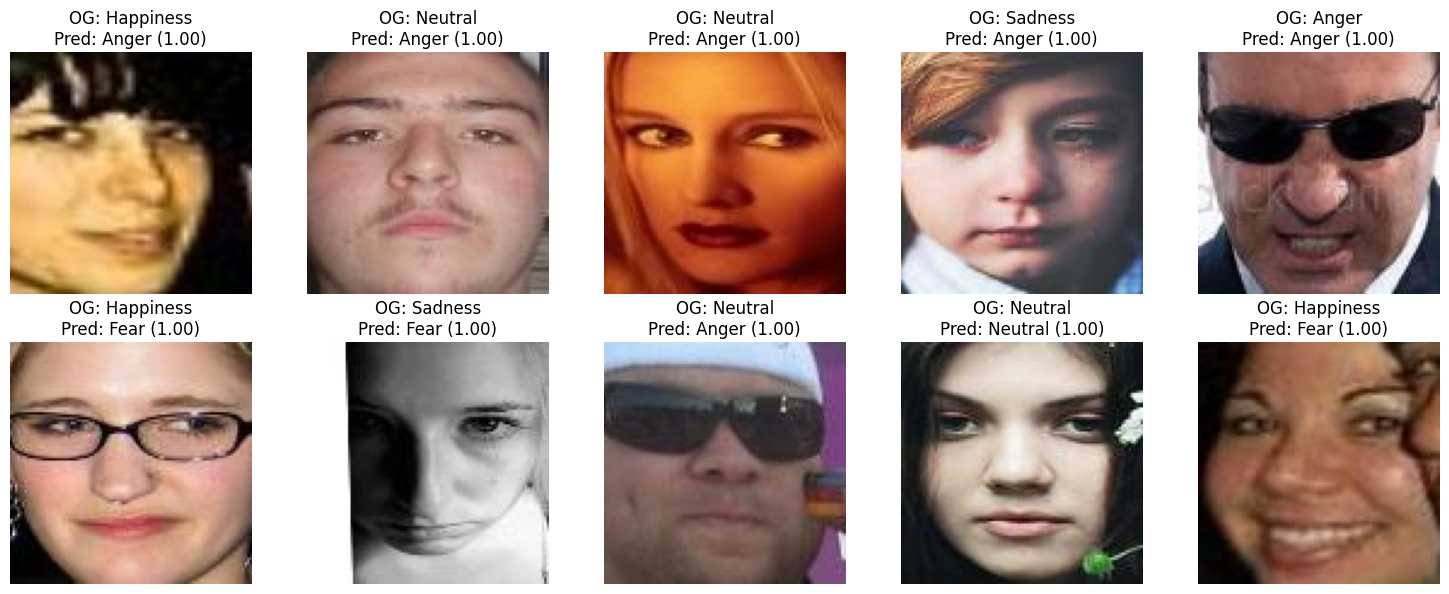

In [41]:
emotion_map = { 0: 'Surprise', 1: 'Fear', 2: 'Disgust', 3: 'Happiness', 4: 'Sadness', 5: 'Anger', 6: 'Neutral' }
data_show_with_pred(test_df, test_dir, emotion_map, Normal_model)

## Save Normal model

In [42]:
Normal_model.save("emotion_model_N.h5")